<a href="https://colab.research.google.com/github/M-Nafay-Ali/Credit-Card_Fraud-Analysis-and-Model/blob/main/credit_card_frauds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


As usual in this step we use to load our dataset and get some information about our data as we always do then we decide to what to do as understanding dataset is crucial because it will lead to further steps

In [ ]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/credit_card_frauds.csv")
print(df)
print('Now to get some idea about our data ')
print(df.head())
print("Now to get information about datatypes in our data set")
print(df.info())

       trans_date_trans_time                   merchant        category  \
0        2019-01-01 00:00:44  Heller, Gutmann and Zieme     grocery_pos   
1        2019-01-01 00:00:51             Lind-Buckridge   entertainment   
2        2019-01-01 00:07:27                  Kiehn Inc     grocery_pos   
3        2019-01-01 00:09:03                Beier-Hyatt    shopping_pos   
4        2019-01-01 00:21:32                 Bruen-Yost        misc_pos   
...                      ...                        ...             ...   
339602   2020-12-31 23:57:56             Schmidt-Larkin            home   
339603   2020-12-31 23:58:04  Pouros, Walker and Spence       kids_pets   
339604   2020-12-31 23:59:07            Reilly and Sons  health_fitness   
339605   2020-12-31 23:59:15                  Rau-Robel       kids_pets   
339606   2020-12-31 23:59:24            Breitenberg LLC          travel   

           amt                      city state      lat      long  city_pop  \
0       107.23      

Since the transaction date and time is in object we first need it to convert it into string

In [ ]:
df['trans_date_trans_time']=pd.to_datetime(df['trans_date_trans_time'])
#Extracting hours and creating new column named "hour"#
df['hour']=df['trans_date_trans_time'].dt.hour
#check the first few rows and confirm if it works
print(df[['trans_date_trans_time', 'hour']].head())

  trans_date_trans_time  hour
0   2019-01-01 00:00:44     0
1   2019-01-01 00:00:51     0
2   2019-01-01 00:07:27     0
3   2019-01-01 00:09:03     0
4   2019-01-01 00:21:32     0


Now we check the number of frauds we are doing it with a simple linechart from matplotlib

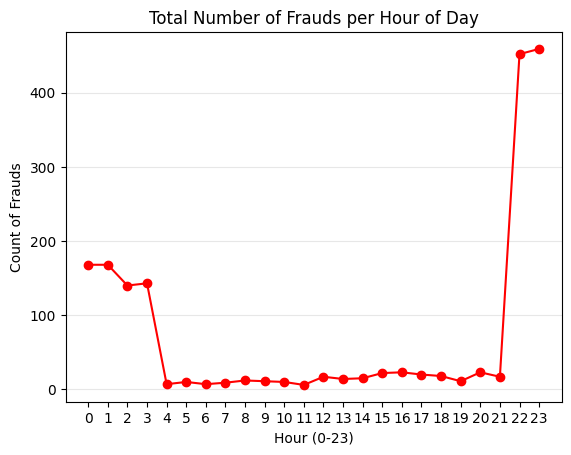

In [ ]:

import matplotlib.pyplot as plt

#Group by the 'hour' column and count only the frauds (is_fraud == 1)
fraud_per_hour = df[df['is_fraud'] == 1].groupby('hour').size()

#Reindex to ensure all 24 hours are shown (even if some have 0 fraud)
fraud_per_hour = fraud_per_hour.reindex(range(24), fill_value=0)

#Creating the Line Chart
plt.plot(fraud_per_hour.index, fraud_per_hour.values, marker='o', color='red', linestyle='-')

#Add labels and title
plt.title('Total Number of Frauds per Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Count of Frauds')
plt.xticks(range(24))
plt.grid(True, axis='y', alpha=0.3)

#Save the plot
plt.savefig('fraud_per_hour_chart.png')

Now we are checking if fraud is only targeting old people's or only teenagers
And This step is Feature Engineering.

In [ ]:
# First we need to convert Date of birth column(dob) to date and time format as previous so that we can get age by subtracting it with current year (2026)


#Converting dob to datetime
df['dob'] = pd.to_datetime(df['dob'])

# 2. Calculate age using 2026 as the current year
df['age'] = 2026 - df['dob'].dt.year

Now we are creating boxplot bcz it shows the median, quartiles, and outliers all at once, making it easy to compare the two groups.

/tmp/ipykernel_2362/3073319638.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='age', data=df, palette='Set3')


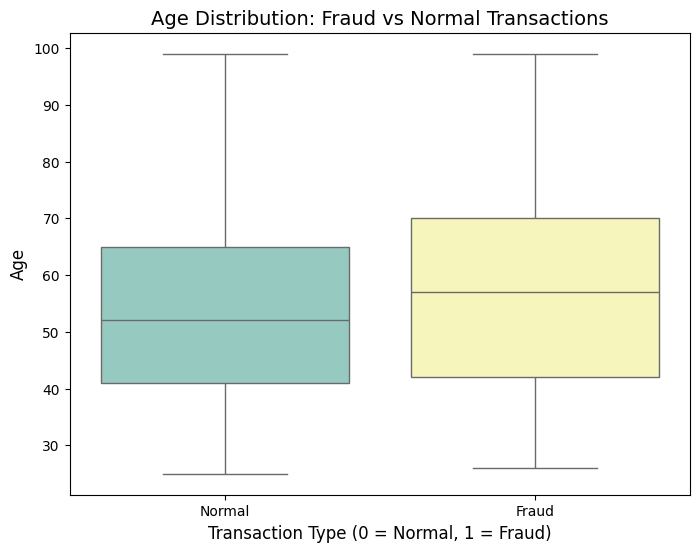

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Create the boxplot comparing 'is_fraud' groups
sns.boxplot(x='is_fraud', y='age', data=df, palette='Set3')

# Customizing the labels
plt.title('Age Distribution: Fraud vs Normal Transactions', fontsize=14)
plt.xlabel('Transaction Type (0 = Normal, 1 = Fraud)', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.show()


When looking at your plot, compare the middle line (the median) and the height of the boxes:

•Higher Box (Older): If the "Fraud" box sits higher than the "Normal" box, it suggests that elderly people are being targeted more frequently. Fraudsters often target seniors because they may be less familiar with digital security

•Lower Box (Younger): If the "Fraud" box is lower, it might indicate that younger people (teenagers/young adults) are the primary victims, perhaps due to higher social media activity or frequent online shopping on less secure sites

•Overlap: If the boxes are at the same level, it means age might not be a significant factor in this specific dataset.

In [ ]:
print("By seeing graph we get to know that elderly people mostly get targeted by the frauds")

By seeing graph we get to know that elderly people mostly get targeted by the frauds


In this we are going to get the information about frauds that if the fraud happen more in big cities like Karachi/New York, or in small rural towns?
The Goal: Use the city_pop column.

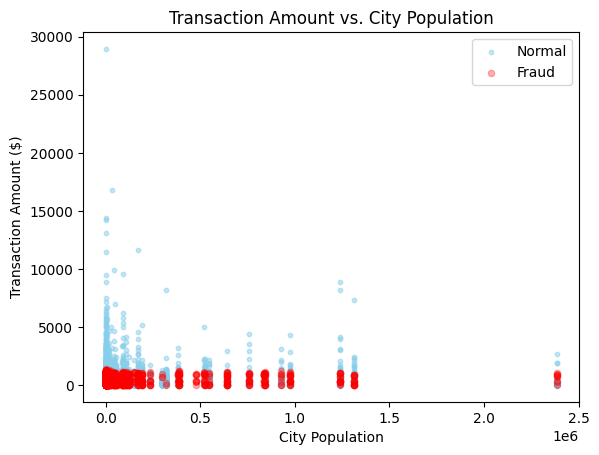

In [ ]:

import matplotlib.pyplot as plt

#Plot normal transactions (is_fraud == 0) in a lighter color
plt.scatter(df[df['is_fraud'] == 0]['city_pop'],
            df[df['is_fraud'] == 0]['amt'],
            alpha=0.5,
            label='Normal',
            color='skyblue',
            s=10)

#Plot fraud transactions (is_fraud == 1) in red on top
plt.scatter(df[df['is_fraud'] == 1]['city_pop'],
            df[df['is_fraud'] == 1]['amt'],
            alpha=0.3,
            label='Fraud',
            color='red',
            s=20)

#Add labels and title
plt.xlabel('City Population')
plt.ylabel('Transaction Amount ($)')
plt.title('Transaction Amount vs. City Population')
plt.legend()


When you examine the chart, look for where the red dots are grouping:


•The "Rural" Cluster: If the red dots are mostly on the left side of the X-axis (low population), it suggests that people in small towns are more vulnerable. This often happens because smaller financial institutions in rural areas might have had slower updates to their security protocols.


•The "High Value" Fraud: Check Y-axis. Are the red dots generally higher up than the blue ones? Fraudulent transactions often have a higher amount ($amt$) than the average $20$ or $50$ dollar grocery trips.

•The"Big City" Mystery: If you see very few red dots on the far right (high population), it might be because big-city banks have more aggressive AI monitoring that blocks fraud before it even happens

FROM GRAPH(SCATTER PLOT) WE GET TO KNOW THAT POPULATION MATTERS AS FRAUDS MOSTLY TARGET LOW POPULATION AREAS SO THAT THEY CAN AVOID HIGH ALARMING SECURITY SYSTEMS BECAUSE SMALL TOWNS ARE MOSTLY VULNERABLE AS COMPARED TO POPULATION DENSE AREAS

Now from now on we are going towards Machine Learning (Predictive Modeling)

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Define X and y
X = df[['amt', 'city_pop', 'hour', 'age']]
y = df['is_fraud']

# 2. Split (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the model
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# 4. Make predictions
predictions = model.predict(X_test)

# 5. Check results
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     67555
           1       0.76      0.53      0.63       367

    accuracy                           1.00     67922
   macro avg       0.88      0.77      0.81     67922
weighted avg       1.00      1.00      1.00     67922



•Understanding My Score
Accuracy (1.00 or 99%): At first glance, this looks perfect. However, in fraud detection accuracy is a "trap."

•Recall for Class 1 (Fraud): We likely see a score around 0.54.
What this means: Your model is catching about 54% of the frauds.

•The Problem: While the model is good, a bank would want to catch more than half of the thieves!

Now to solve the problem

•The problem:-The Model is struggling to catch all the fraud is because of Class Imbalance.

•In our dataset, there are 67,555 normal transactions but only 367 fraud cases
•The model "sees" so many normal transactions that it becomes biased toward guessing "Not Fraud"

The solution:-To fix this we can use a technique called Over-sampling.We basically "copypaste" the fraud examples so the model sees them more often during training

In [ ]:
from imblearn.over_sampling import RandomOverSampler

#Create the sampler
ros =RandomOverSampler(random_state=42)

# Re-sample ONLY the training data
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

# Now train the model on X_resampled and y_resampled
model.fit(X_resampled, y_resampled)

RandomForestClassifier()

Now at then end we are looking that which factor leads to frauds like is it age or is it ammont or what...

In [45]:
import pandas as pd
import plotly.express as px

# 1. Get the importance scores from your model
importances = model.feature_importances_
feature_names = ['amt', 'city_pop', 'hour', 'age']

# 2. Create a DataFrame for the plot
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# 3. Create a Bar Chart
fig_imp = px.bar(feature_df, x='Importance', y='Feature',
                 orientation='h',
                 title='What Clues Does the Model Use Most to Find Fraud?',
                 color='Importance',
                 color_continuous_scale='Bluered',
                 template='plotly_dark')
fig_imp.show()

At the end we get to know that it is amount which lead to most frauds as frauds are doing it for money and amount is most targeted factor in frauds